In [159]:
import matplotlib.pyplot as plt
import numpy as np
from mytools.construct import all_armchair as struct
import sisl
from scipy.spatial import cKDTree

In [196]:
def plot_atoms(xyz, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        pass
    
    ax.scatter(xyz[:, 0], xyz[:, 1], s=120)
    coords = xyz[:, :2]
    for i, (x, y) in enumerate(coords):
        ax.text(x, y, str(i), fontsize=8, verticalalignment='center', horizontalalignment='center',
                bbox=dict(facecolor='white',alpha=0.7,edgecolor='none', pad=0.1)
                )
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Atom positions with indices')
    

In [419]:
BOND = 1.42
R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

N1 = 4
N2 = 7

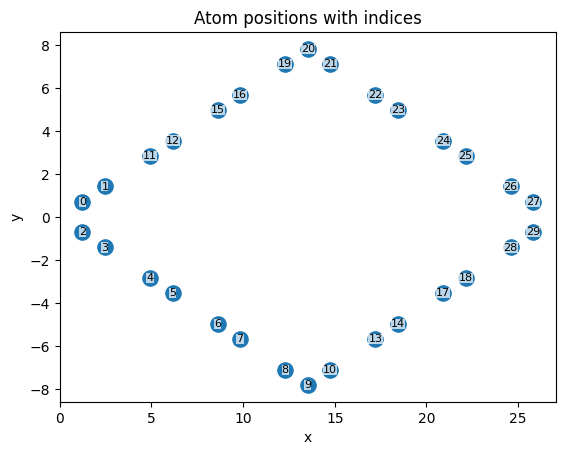

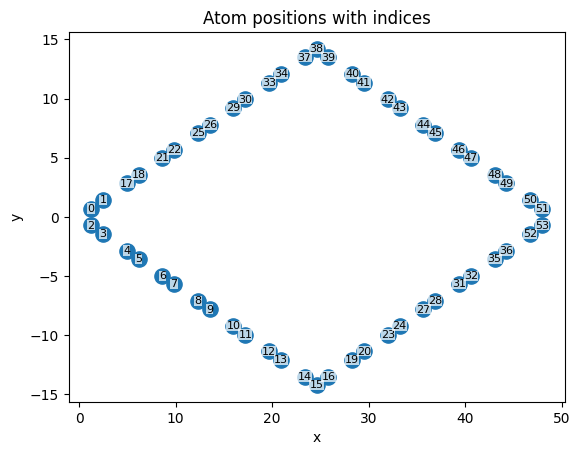

In [420]:
graphene6 = struct(BOND)
Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

RSE1 = sisl.RealSpaceSE(Ham0, 0, 1, (N1, N1, 1))
RSE2 = sisl.RealSpaceSE(Ham0, 0, 1, (N2, N2, 1))

Ham1 = RSE1.real_space_parent()
Ham2 = RSE2.real_space_parent()

HamElec1, Elec1 = RSE1.real_space_coupling(ret_indices=True)
HamElec2, Elec2 = RSE2.real_space_coupling(ret_indices=True)
plot_atoms(HamElec1.xyz)
plot_atoms(HamElec2.xyz)

In [421]:
xyz1 = HamElec1.xyz
xyz2 = HamElec2.xyz

Ham0.geometry.icell, np.linalg.inv(Ham0.cell)

(array([[ 0.13552823, -0.23474178,  0.        ],
        [ 0.13552823,  0.23474178, -0.        ],
        [-0.        ,  0.        ,  0.05      ]]),
 array([[ 0.13552823,  0.13552823,  0.        ],
        [-0.23474178,  0.23474178,  0.        ],
        [ 0.        ,  0.        ,  0.05      ]]))

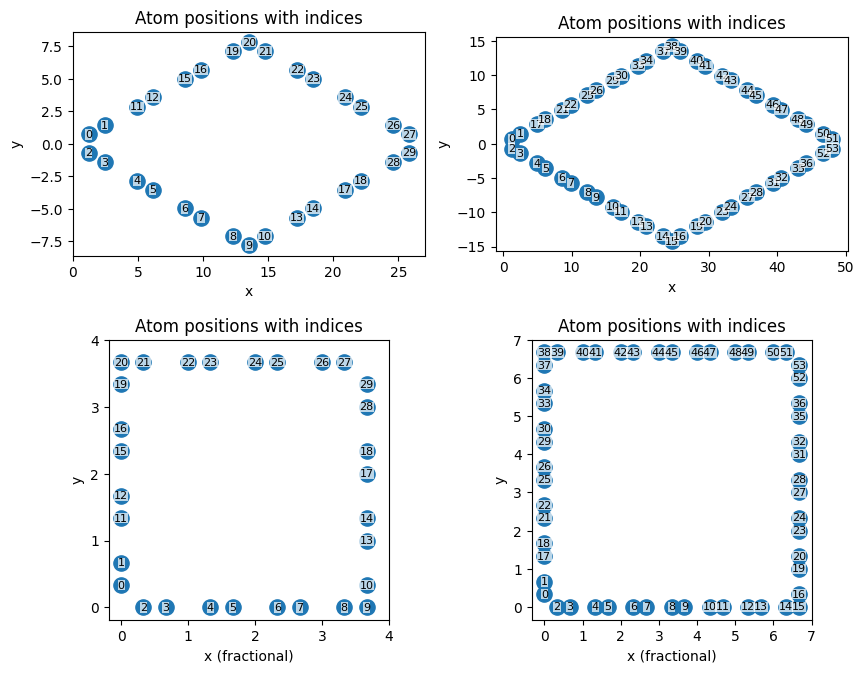

In [422]:
use_custom = True

if use_custom:
    Inv = lambda H: np.linalg.inv(H.cell)
else:
    Inv = lambda H: H.rcell

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_atoms(xyz1, ax=axes[0, 0])
# plot_atoms(Ham1.remove(Elec1).xyz, ax=axes[0, 0])

plot_atoms(xyz1 @ Inv(Ham0), ax=axes[1,0])
# plot_atoms(Ham1.remove(Elec1).xyz @ Inv(Ham0), ax=axes[1,0])

plot_atoms(xyz2, ax=axes[0,1])
# plot_atoms(Ham2.remove(Elec2).xyz, ax=axes[0,1])

plot_atoms(xyz2 @ Inv(Ham0), ax=axes[1, 1])
# plot_atoms(Ham2.remove(Elec2).xyz @ Inv(Ham0), ax=axes[1, 1])


for ax in axes.flatten():
    ax.set_aspect('equal')
    
for ax, m in zip(axes[1, :], [np.max(frac1), np.max(frac2)]):
    ax.set_xlabel('x (fractional)')
    ax.set_xticks(np.arange(0, np.ceil(m)+1, 1))
    ax.set_yticks(np.arange(0, np.ceil(m)+1, 1))
# fig.set_constrained_layout(True)

/tmp/ipykernel_16104/1503335038.py:6: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_16104/1503335038.py:7: RuntimeWarning:

invalid value encountered in divide



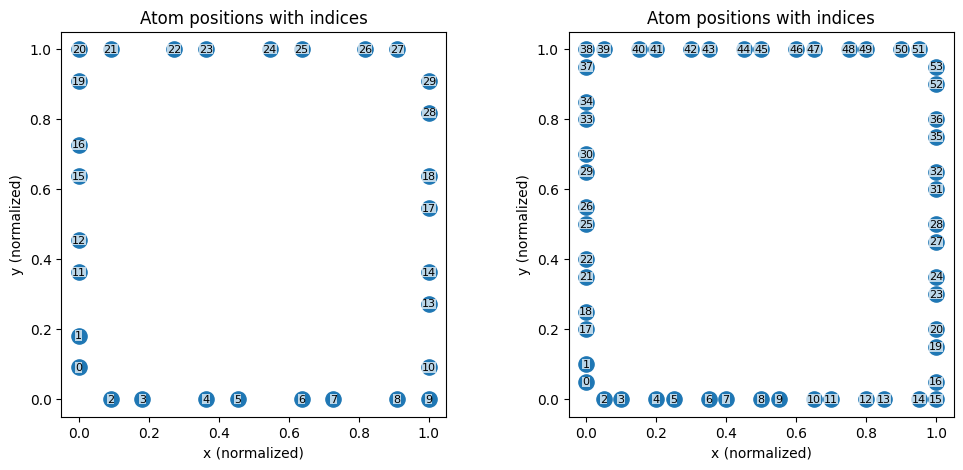

In [423]:
frac1 = xyz1 @ np.linalg.inv(Ham0.cell)
frac2 = xyz2 @ np.linalg.inv(Ham0.cell) 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_atoms(frac1 / np.max(frac1, axis=0, keepdims=True), ax=axes[0])
plot_atoms(frac2 / np.max(frac2, axis=0, keepdims=True), ax=axes[1])

for ax in axes:
    ax.set_aspect(1.)
    ax.set_xlabel('x (normalized)')
    ax.set_ylabel('y (normalized)')

In [424]:
def get_fractional(geom):
    """Map Cartesion coordinates to fractional coordinates, 
    between 0 and 1 representing position relative to unitcell vertices."""
    Inv = np.linalg.inv(geom.cell[:2, :2])
    frac = geom.xyz[:, :2] @ Inv
    return frac / np.max(frac, axis=0, keepdims=True)

def get_corner_atoms(coords, corner, k=1):
    
    tree = cKDTree(coords)
    dists, idxs = tree.query(corner, k=k)
    return idxs


def find_corners(fcoords):
    """Find the corners of the fractional coordinate space."""
    corners = np.array([[0, 0], [1, 0], [0, 1], [1, 1]])
    tree = cKDTree(corners)
    _, indices = tree.query(fcoords)
    return indices

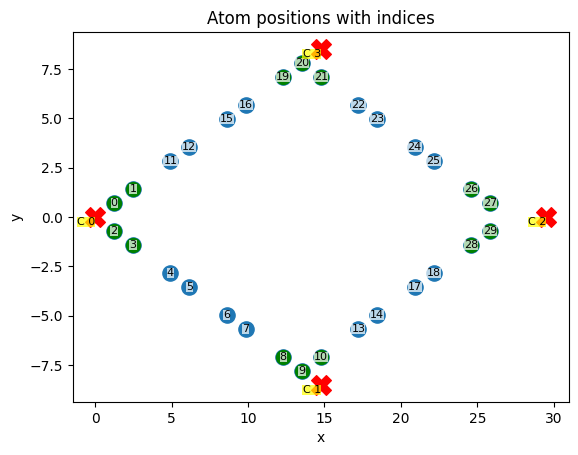

In [425]:
frac1 = get_fractional(HamElec1)
fig, ax = plt.subplots()
plot_atoms(xyz1, ax=ax)
A, B, C = HamElec1.cell
corners = np.array([A-A, A, A+B, B])

ax.scatter(corners[:, 0], corners[:, 1], color='red', s=200, marker='X')
for ic, (c, k) in enumerate(zip(corners, [4,3,4,3])):
    ax.text(c[0], c[1], f'C {ic}', fontsize=8, verticalalignment='top', horizontalalignment='right',
            bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=0.1)
            )
    idxs = get_corner_atoms(xyz1, c, k=k)
    ax.scatter(xyz1[idxs, 0], xyz1[idxs, 1], color='green', s=100, marker='o')
        

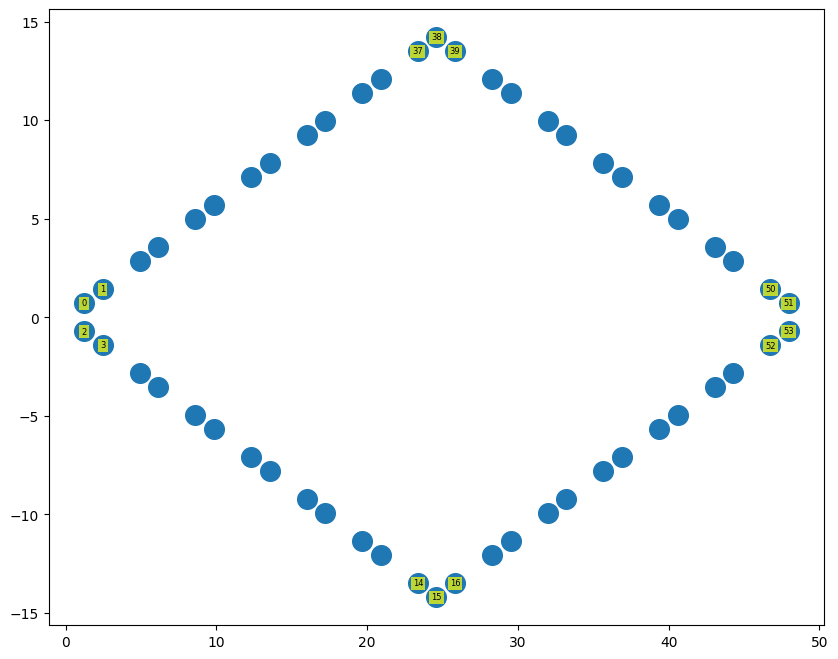

In [426]:
def find_corners(geom):
    A, B, _ = geom.cell
    corners = np.array([A-A, A, A+B, B])
    ks = np.array([4, 3, 4, 3])
    idxs = {}
    labels = ['0', 'A', 'A+B', 'B']
    for c, k, lab in zip(corners, ks, labels):
        idx = get_corner_atoms(geom.xyz, c, k)
        idxs[lab] = idx
    return idxs

H = HamElec2
idxs = find_corners(H)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(H.xyz[:, 0], H.xyz[:, 1], s=200)
for lab, idx in idxs.items():
    # ax.scatter(H.xyz[idx, 0], H.xyz[idx, 1], color='red', s=50, marker='X')
    for i in idx:
        ax.text(H.xyz[i, 0], H.xyz[i, 1], i, fontsize=6, verticalalignment='center', horizontalalignment='center',
                bbox=dict(facecolor='yellow',alpha=0.7, edgecolor='none', pad=1.5)
                )
        

In [ ]:
def find_edge_pairs(geom, corners, bond_threshold=1.5):
    """Find pairs of atoms that are connected by an edge, 
    and belong to different corners."""
    
    tree = cKDTree(geom.xyz)
    pairs = []
    for i in range(len(geom)):
        dists, idxs = tree.query(geom.xyz[i], k=10)
        for dist, idx in zip(dists, idxs):
            if dist < bond_threshold and idx != i:
                # Check if they belong to different corners
                corner_i = None
                corner_j = None
                for lab, idxs in corners.items():
                    if i in idxs:
                        corner_i = lab
                    if idx in idxs:
                        corner_j = lab
                if corner_i is not None and corner_j is not None and corner_i != corner_j:
                    pairs.append((i, idx))
    return pairs